# EV Charging Stations — Insights & Analysis

**Input:** `8486_cleaned_analysis.csv` (570 rows), the analysis-ready output of the cleaning notebook.

**Unit of analysis: STATE.** The raw `city` field is a *list* of cities per reporting row, so per-city
numbers are ambiguous. The `State` column is clean and unambiguous, so all questions are answered at the
state level. Where useful, we also list the unique cities that fall under each state.

### Questions
1. **Q1** — Which states have the most EV charging stations?
2. **Q2** — Which states consume the most electricity for EV charging?
3. **Q3** — Utilisation index: which states work their stations hardest (electricity per station)?
4. **Q4** — How has the number of EV stations grown month over month?

---
### A key methodological note: *stock vs. flow*
- **Stations are a _stock_** — a station that exists in August still exists in September. Summing station
  counts across the 20 months would **double-count** the same physical stations. So for station counts we
  use the **latest-month snapshot** (the most recent count available for each state).
- **Electricity is a _flow_** — energy consumed in August plus September really is the total for those two
  months. So for electricity we **sum across all months**.

This distinction drives how each question is aggregated below.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('/Users/anahitasaxena/Desktop/EV DA/8486_cleaned_analysis.csv')   # adjust path if needed
print('Loaded:', df.shape)

# Combined measures (EV + heavy-duty), as agreed. Treat NaN as 0 for summation only.
df['stations_total'] = df['ev_stations'].fillna(0) + df['hd_stations'].fillna(0)
df['kwh_total']      = df['ev_kwh'].fillna(0)      + df['hd_kwh'].fillna(0)

# A proper month-start date for ordering (built from the clean year/month columns)
df['date'] = pd.to_datetime(dict(year=df['calendar_year'], month=df['calendar_month'], day=1))
print('Months covered:', df['date'].min().strftime('%b-%Y'), 'to', df['date'].max().strftime('%b-%Y'))
df.head()

Loaded: (570, 12)
Months covered: Apr-2022 to Nov-2023


,Country,financial_year,calendar_year,calendar_month,DISCOM,State,city,ev_stations,hd_stations,ev_kwh,hd_kwh,total_mu,stations_total,kwh_total,date
0,India,2023-24,2023,8,HESCOM,KAR,hubli,12.0,0.0,12807.0,0.0,0.013,12.0,12807.0,2023-08-01
1,India,2023-24,2023,9,HESCOM,KAR,hubli,22.0,0.0,11790.0,0.0,0.012,22.0,11790.0,2023-09-01
2,India,2023-24,2023,9,APEPDCL,AP,"visakhapatnam, rajmahendravaram, west godavari...",70.0,0.0,22216.0,0.0,0.022,70.0,22216.0,2023-09-01
3,India,2023-24,2023,9,NBPDCL,BIHAR,patna,204.0,0.0,32693.0,0.0,0.033,204.0,32693.0,2023-09-01
4,India,2023-24,2023,9,GESCOM,KAR,kalaburgi,1.0,0.0,1498.0,0.0,0.001,1.0,1498.0,2023-09-01


## Q1 — Which states have the most EV charging stations?

**Aggregation:** latest-month snapshot per state (stock — avoids double-counting). For each state we take
its most recent reporting month and sum the stations across that state's rows in that month.

In [2]:
def latest_snapshot_stations(g):
    last_month = g['date'].max()
    return g.loc[g['date'] == last_month, 'stations_total'].sum()

q1 = (df.groupby('State').apply(latest_snapshot_stations)
        .sort_values(ascending=False).rename('stations_latest'))
print(q1.to_string())

State
DELHI         3980.0
MAH           3244.0
BIHAR          588.0
KAR            433.0
GUJ            178.0
TN             139.0
AP             114.0
HARYANA        109.0
MP              97.0
TNG             45.0
WB              23.0
RAJ             22.0
ASSAM           10.0
CHANDIGARH       7.0
UP               5.0
KER              5.0
ORISSA           0.0
JHARKHAND        0.0


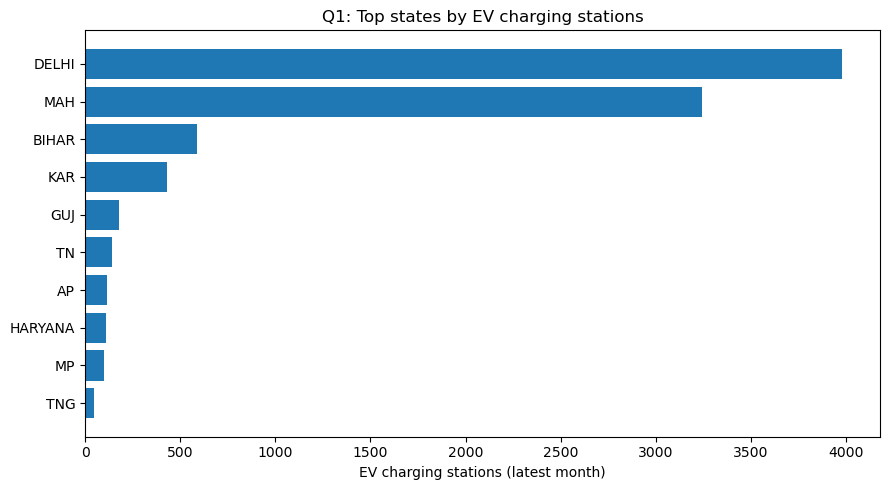

In [3]:
# Visualise top 10
top = q1.head(10)[::-1]
plt.figure(figsize=(9,5))
plt.barh(top.index, top.values)
plt.xlabel('EV charging stations (latest month)')
plt.title('Q1: Top states by EV charging stations')
plt.tight_layout(); plt.show()

### Unique cities under each state
The `city` field lists multiple cities per row. Here we split and dedupe them to show which cities make
up each state's footprint.

In [4]:
def unique_cities(s):
    out = set()
    for entry in s.dropna():
        for c in str(entry).split(','):
            c = c.strip()
            if c:
                out.add(c)
    return sorted(out)

cities_by_state = df.groupby('State')['city'].apply(unique_cities)
for st in q1.head(5).index:
    print(f"\n{st} ({len(cities_by_state[st])} cities):")
    print('  ', ', '.join(cities_by_state[st]))


DELHI (1 cities):
   new delhi

MAH (5 cities):
   mumbai (best), nagpur, navi mumbai, pune, thane

BIHAR (1 cities):
   patna

KAR (15 cities):
   bangalore, chikkamagaluru, chitradurga, davangere, hassan, hubli, kalaburgi, kodagu, kolar, mandya, mangaluru, mysore, shivamogga, tumkuru, udupi

GUJ (23 cities):
   ahemdabad, asal, bavla (ramnagar), bavla(ramnagar), bharuch east, botad, dholasan, fedra, haldarva, hebatpur, jamnagar, junagadh, kavadiya colony, majadar, modasa, morbi, navsari, nugar, rajkot, rangpur, surat city, surendranagar, vapi-town


## Q2 — Which states consume the most electricity for EV charging?

**Aggregation:** sum of `kwh_total` across all months (flow — summing is correct for energy).

In [5]:
q2 = (df.groupby('State')['kwh_total'].sum()
        .sort_values(ascending=False).rename('total_kwh'))
print((q2/1000).round(1).rename('total_MWh').to_string())   # shown in MWh for readability

State
DELHI         252651.2
MAH           157783.9
GUJ            59715.1
HARYANA         8869.7
AP              8868.7
RAJ             5960.8
CHANDIGARH      5108.2
WB              4861.5
KAR             3879.3
ASSAM           3579.1
TNG             3416.5
BIHAR           3245.8
TN              2309.9
KER             2179.5
MP              1090.6
UP                35.6
ORISSA            24.3
JHARKHAND         14.4


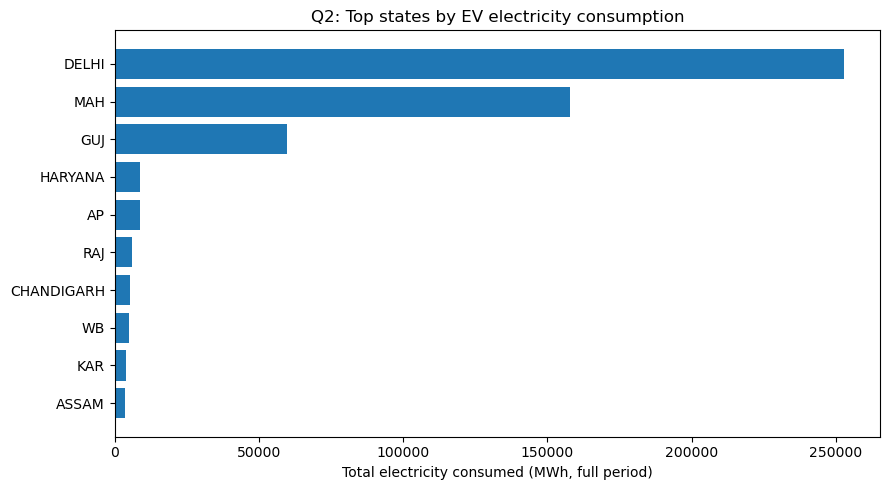

In [6]:
top = q2.head(10)[::-1] / 1000  # MWh
plt.figure(figsize=(9,5))
plt.barh(top.index, top.values)
plt.xlabel('Total electricity consumed (MWh, full period)')
plt.title('Q2: Top states by EV electricity consumption')
plt.tight_layout(); plt.show()

## Q3 — Utilisation index (electricity per station)

**The idea (yours):** how hard is each station working? A state with high electricity but few stations is
running its stations intensively; low electricity per station means lightly used infrastructure.

**The logic — ratio of sums, not average of ratios.** We compute:

$$\text{Utilisation}_{\text{state}} = \frac{\text{total kWh over the whole period}}{\text{station count (latest snapshot)}}$$

We deliberately use the **ratio of aggregates** rather than averaging each row's (kWh ÷ stations):
row-level ratios explode when a row has very few stations, distorting the result. Taking total energy over
the period per existing station gives a stable, interpretable "lifetime energy served per station" figure.
States with zero stations in their latest snapshot are excluded (division undefined).

In [7]:
util = pd.DataFrame({'total_kwh': q2, 'stations_latest': q1})
util = util[util['stations_latest'] > 0]               # guard against divide-by-zero
util['utilisation_kwh_per_station'] = util['total_kwh'] / util['stations_latest']
util = util.sort_values('utilisation_kwh_per_station', ascending=False)
print(util['utilisation_kwh_per_station'].round(0).to_string())

State
CHANDIGARH    729747.0
KER           435894.0
ASSAM         357915.0
GUJ           335478.0
RAJ           270947.0
WB            211370.0
HARYANA        81373.0
AP             77796.0
TNG            75923.0
DELHI          63480.0
MAH            48639.0
TN             16618.0
MP             11244.0
KAR             8959.0
UP              7113.0
BIHAR           5520.0


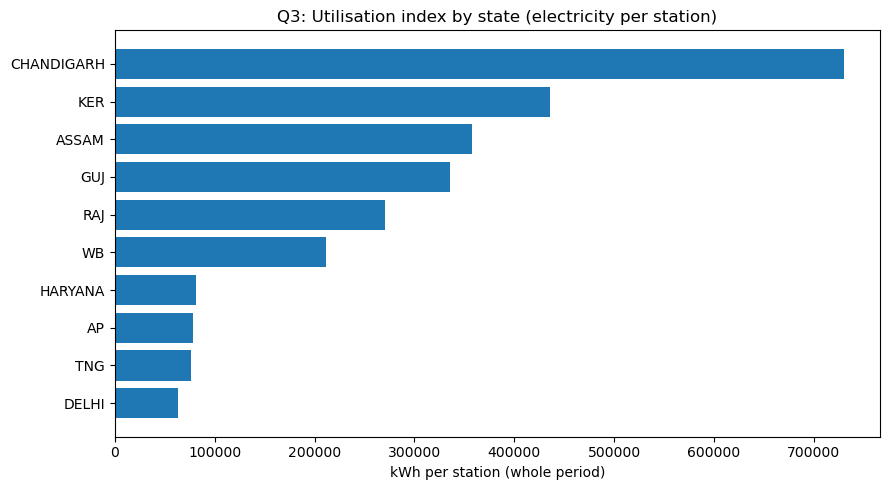

In [8]:
top = util['utilisation_kwh_per_station'].head(10)[::-1]
plt.figure(figsize=(9,5))
plt.barh(top.index, top.values)
plt.xlabel('kWh per station (whole period)')
plt.title('Q3: Utilisation index by state (electricity per station)')
plt.tight_layout(); plt.show()

## Q4 — How has the number of EV stations grown over time?

**Aggregation:** for each month, sum the stations reported across all states (each month is one snapshot,
so summing *within* a month is correct; we then watch the snapshot grow month over month).

In [9]:
monthly = (df.groupby('date')['stations_total'].sum()
             .rename('stations').reset_index().sort_values('date'))
print(monthly.to_string(index=False))

      date  stations
2022-04-01    2780.0
2022-05-01    2889.0
2022-06-01    2986.0
2022-07-01    3046.0
2022-08-01    3215.0
2022-09-01    5590.0
2022-10-01    5678.0
2022-11-01    5851.0
2022-12-01    6269.0
2023-01-01    6433.0
2023-02-01    6572.0
2023-03-01    6790.0
2023-04-01    7397.0
2023-05-01    7673.0
2023-06-01    7862.0
2023-07-01    7938.0
2023-08-01   13338.0
2023-09-01    9623.0
2023-10-01    9626.0
2023-11-01    8763.0


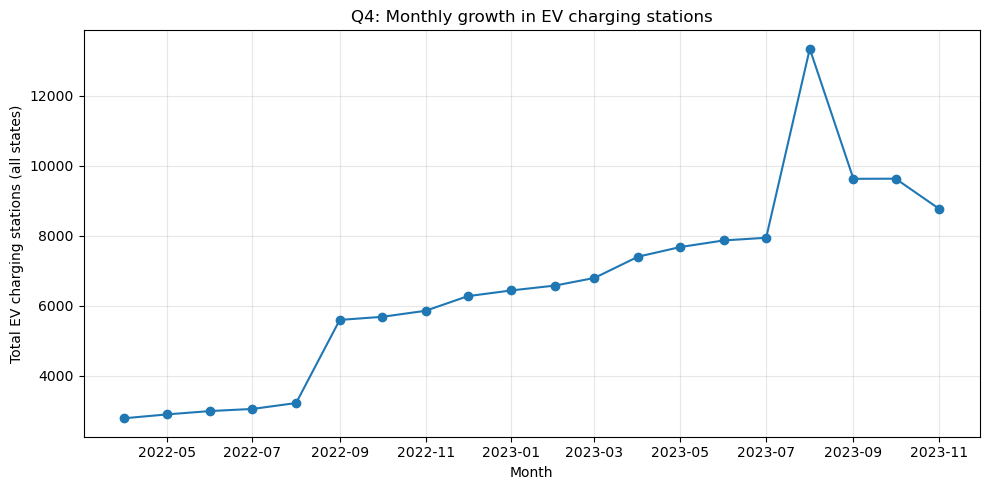

In [10]:
plt.figure(figsize=(10,5))
plt.plot(monthly['date'], monthly['stations'], marker='o')
plt.xlabel('Month'); plt.ylabel('Total EV charging stations (all states)')
plt.title('Q4: Monthly growth in EV charging stations')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [11]:
# Simple growth summary
first, last = monthly.iloc[0], monthly.iloc[-1]
print(f"Start: {first['stations']:.0f} stations in {first['date']:%b-%Y}")
print(f"End:   {last['stations']:.0f} stations in {last['date']:%b-%Y}")
if first['stations'] > 0:
    print(f"Growth over period: {100*(last['stations']-first['stations'])/first['stations']:.0f}%")

Start: 2780 stations in Apr-2022
End:   8763 stations in Nov-2023
Growth over period: 215%


## Summary

- **Q1 (stations, latest snapshot):** ranks states by how many EV charging stations physically exist.
- **Q2 (electricity, summed):** ranks states by total energy delivered for EV charging over the period.
- **Q3 (utilisation):** total energy per existing station — identifies intensively- vs lightly-used networks.
- **Q4 (trend):** the month-over-month trajectory of station rollout.

Caveats kept in mind throughout: partial nulls are treated as 0 *only for summation*; the city field is a
multi-city list (so analysis is at state level); and stock-vs-flow aggregation is applied per question.